##### Copyright 2020 Google LLC.

## SimCLR: A Simple Framework for Contrastive Learning of Visual Representations

This notebook demonstrates how to fine-tune a pretrained SimCLRv2 model on a downstream task.

**Updated:** Rewritten in **PyTorch** using official SimCLRv2 weights from HuggingFace (`lightly-ai/simclrv2-imagenet1k-r50_1x_sk0`).
The backbone is frozen and only a new linear head is trained on the tf_flowers dataset (5 classes).


In [ ]:
!pip install torch torchvision huggingface_hub tensorflow_datasets matplotlib numpy --quiet


In [ ]:
import re
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import DataLoader, Dataset
from huggingface_hub import hf_hub_download
import tensorflow_datasets as tfds
import matplotlib
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

tf_flowers_labels = ['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']


Using device: cuda


In [ ]:
# ─────────────────────────────────────────────────────────────
# Preprocessing (mirrors the original preprocess_for_eval)
# ─────────────────────────────────────────────────────────────
preprocess_eval = T.Compose([
    T.ToPILImage(),
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

preprocess_train = T.Compose([
    T.ToPILImage(),
    T.RandomResizedCrop(224),
    T.RandomHorizontalFlip(),
    T.ColorJitter(0.4, 0.4, 0.4, 0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Simple PyTorch Dataset wrapping tfds
class FlowersDataset(Dataset):
    def __init__(self, split='train', transform=None):
        self.data = list(tfds.load('tf_flowers', split=split, as_supervised=False))
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        img = sample['image'].numpy()
        label = int(sample['label'].numpy())
        if self.transform:
            img = self.transform(img)
        return img, label

batch_size = 64
dataset = FlowersDataset(split='train', transform=preprocess_train)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

num_classes = 5  # tf_flowers
num_images = len(dataset)
print(f'Dataset size: {num_images} images, {num_classes} classes')


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.AWM8QU_3.0.1/tf_flowers-train.tfrecord*...:   0%|   …

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.
Dataset size: 3670 images, 5 classes


In [ ]:
# ─────────────────────────────────────────────────────────────
# Load SimCLRv2 backbone from HuggingFace
# Replaces: hub.Module('gs://simclr-checkpoints/...')
# ─────────────────────────────────────────────────────────────

REPO_ID = 'lightly-ai/simclrv2-imagenet1k-r50_1x_sk0'
ckpt_path = hf_hub_download(repo_id=REPO_ID, filename='r50_1x_sk0.pth')

backbone = models.resnet50(weights=None)
backbone.fc = nn.Identity()   # remove original head, output is [B, 2048]

state_dict = torch.load(ckpt_path, map_location=device)
backbone.load_state_dict(state_dict, strict=False)

# Freeze backbone — only the new linear head will be trained
for param in backbone.parameters():
    param.requires_grad = False

backbone = backbone.to(device)
backbone.eval()
print('SimCLRv2 backbone loaded and frozen.')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


r50_1x_sk0.pth:   0%|          | 0.00/137M [00:00<?, ?B/s]

SimCLRv2 backbone loaded and frozen.


In [ ]:
# ─────────────────────────────────────────────────────────────
# Attach a trainable linear head (mirrors head_supervised_new)
# ─────────────────────────────────────────────────────────────

learning_rate = 0.1
momentum      = 0.9
weight_decay  = 0.0

class SimCLRFineTuner(nn.Module):
    def __init__(self, backbone, num_classes):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Linear(2048, num_classes)  # head_supervised_new

    def forward(self, x):
        with torch.no_grad():
            features = self.backbone(x)   # frozen backbone
        return self.head(features)

model = SimCLRFineTuner(backbone, num_classes).to(device)

# LARS-style: use SGD with momentum (equivalent behaviour for linear head)
optimizer = optim.SGD(
    model.head.parameters(),
    lr=learning_rate,
    momentum=momentum,
    weight_decay=weight_decay
)
criterion = nn.CrossEntropyLoss()

variables_to_train = [n for n, p in model.named_parameters() if p.requires_grad]
print('Parameters to train:', variables_to_train)


Parameters to train: ['head.weight', 'head.bias']


In [ ]:
# ─────────────────────────────────────────────────────────────
# Fine-tune the new linear layer for a few iterations
# (mirrors the original 10-iteration training loop)
# ─────────────────────────────────────────────────────────────

total_iterations = 10
model.train()

data_iter = iter(dataloader)
for it in range(total_iterations):
    try:
        images, labels = next(data_iter)
    except StopIteration:
        data_iter = iter(dataloader)
        images, labels = next(data_iter)

    images, labels = images.to(device), labels.to(device)

    optimizer.zero_grad()
    logits = model(images)
    loss = criterion(logits, labels)
    loss.backward()
    optimizer.step()

    pred = logits.argmax(-1).cpu().numpy()
    true = labels.cpu().numpy()
    correct = np.sum(pred == true)
    total = true.size
    print(f'[Iter {it+1}] Loss: {loss.item():.4f}  Top-1: {correct/float(total):.3f}')


[Iter 1] Loss: 1.7746  Top-1: 0.281
[Iter 2] Loss: 25.8529  Top-1: 0.172
[Iter 3] Loss: 59.4255  Top-1: 0.234
[Iter 4] Loss: 72.9623  Top-1: 0.266
[Iter 5] Loss: 155.9321  Top-1: 0.234
[Iter 6] Loss: 146.3658  Top-1: 0.156
[Iter 7] Loss: 100.7863  Top-1: 0.266
[Iter 8] Loss: 123.1281  Top-1: 0.203
[Iter 9] Loss: 99.2995  Top-1: 0.250
[Iter 10] Loss: 145.2603  Top-1: 0.141


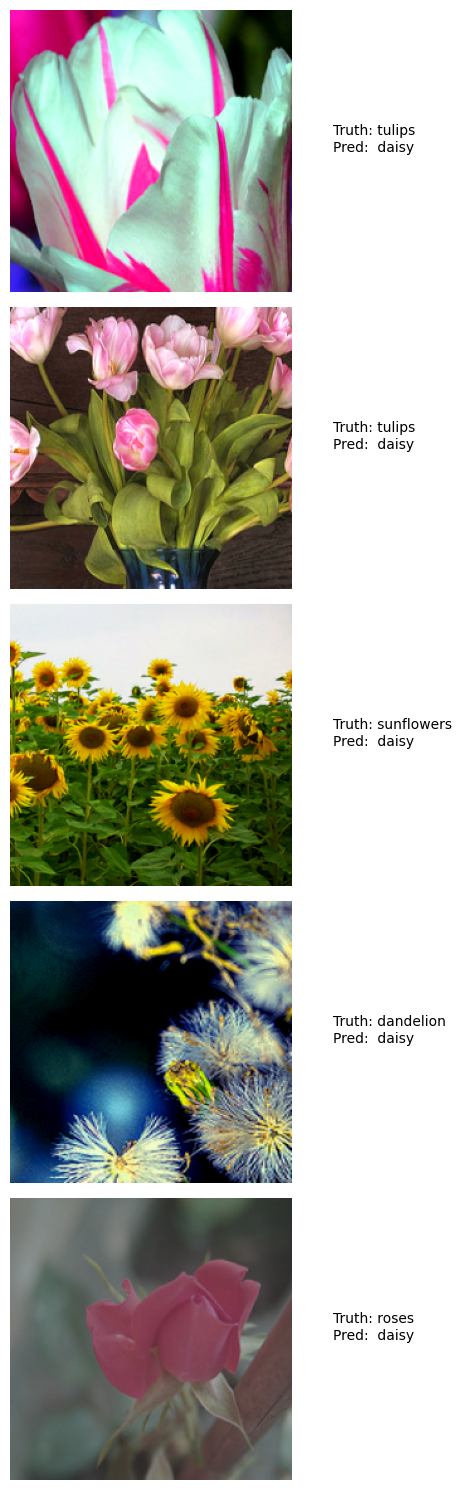

In [ ]:
# ─────────────────────────────────────────────────────────────
# Plot the last batch: images with true and predicted labels
# ─────────────────────────────────────────────────────────────

model.eval()
# Denormalise for display
mean = torch.tensor([0.485, 0.456, 0.406])
std  = torch.tensor([0.229, 0.224, 0.225])

def denorm(t):
    return (t * std[:, None, None] + mean[:, None, None]).clamp(0, 1).permute(1, 2, 0).numpy()

fig, axes = plt.subplots(5, 1, figsize=(15, 15))
for i in range(5):
    axes[i].imshow(denorm(images[i].cpu()))
    true_text = tf_flowers_labels[true[i]]
    pred_text = tf_flowers_labels[pred[i]]
    axes[i].axis('off')
    axes[i].text(256, 112, f'Truth: {true_text}\nPred:  {pred_text}', fontsize=10)
plt.tight_layout()
plt.show()
